<a href="https://colab.research.google.com/github/dionatrafk/model_evaluation/blob/master/GRU_exec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gated Recurrent Unit (GRU)

In [0]:
#Import datasets
!git clone https://github.com/dionatrafk/model_evaluation

*Execution options: **default 60 minute predictions.

**Copy a row of hyperparameters and paste into row 2 of the next cell.**

'trace1.csv', 140, 150, 8, 64 \
'trace5.csv', 130, 130, 128, 64 \
'trace10.csv', 140, 100, 16, 32 \
'trace15.csv', 140, 190, 5, 40 \
'trace20.csv', 140, 200, 50, 45 \
'trace25.csv', 180, 200, 10, 80 \
'trace30.csv', 140, 190, 5, 40  \
'trace35.csv', 180, 200, 10, 80 \
'trace40.csv', 130, 130, 256, 32 \
'trace45.csv', 140, 150, 8, 64 \
'trace50.csv', 130, 130, 60, 60 \
'trace55.csv', 130, 130, 128, 64 \
'trace60.csv', 130, 130, 128, 64 

In [2]:
#definir hiperparâmetros
filename, BATCH_SIZE, NB_EPOCHS, LAYER1, LAYER2 = 'trace_60min.csv', 130, 130, 128, 64

path = 'processed_mit/'
filename = path + filename


c:\VisualStudioCode\PP\Prat_Pesq20261_grp16\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compilation Time :  0:00:00.006002
Training time :  0:00:17.983662
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Samples 4383
Trainscore: 1205.10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step
Test time:  0:00:00.114991
Timer:  0:00:18.649815
Filename: processed_mit/trace_60min.csv
BATCH_SIZE: 130
NB_EPOCHS:  130
LAYER1:  128
LAYER2:  64
R2:  -0.03471481800079346
Testscore: 4770592.50 MSE (2184.17 RMSE)


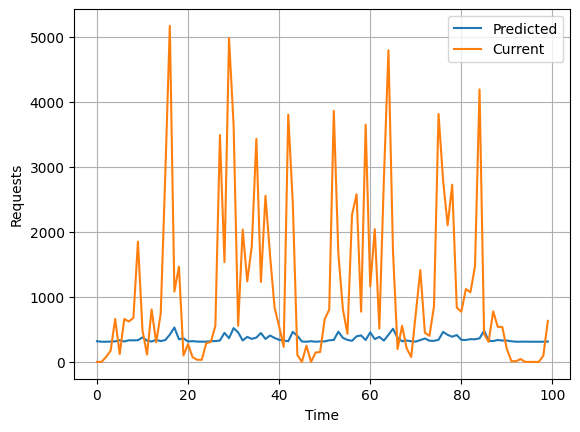

In [3]:
import pandas as pd
from keras.layers import Dense, Dropout, GRU          # Fix: flattened import paths
from keras.models import Sequential, load_model
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import math, datetime
import os, sys

def create_dataset(dataset, lookback=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-lookback-1):
        a = dataset[i:(i+lookback),0]
        dataX.append(a)
        dataY.append(dataset[i+lookback,0])
    return np.array(dataX), np.array(dataY)

# Dataset configuration
dataset = pd.read_csv(filename, usecols=[1], header=None)
dataset.columns = ["request"]
dataset = dataset.values
dataset = dataset.astype('float32')

# Split the dataset
training_size = int(len(dataset)*0.67)
testing_size = len(dataset)-training_size
train, test = dataset[0:training_size:], dataset[training_size:len(dataset),:]

# Create lookback windows
lookback = 1
trainX, trainY = create_dataset(train, lookback)
testX, testY = create_dataset(test, lookback)

# Scaling
x_train, y_train = trainX, trainY
x_test, y_test = testX, testY

scaleX = MinMaxScaler()
scaleY = MinMaxScaler()

trainX = scaleX.fit_transform(x_train)
trainX = trainX.reshape((-1,1,1))
trainY = scaleY.fit_transform(y_train.reshape(-1,1))

testX = scaleX.transform(x_test)             # Fix: use transform (not fit_transform) on test data
testX = testX.reshape((-1,1,1))
testY = scaleY.transform(y_test.reshape(-1,1))

# Build model
model_name = 'requests_GRU'
model = Sequential()
model.add(GRU(units=LAYER1,
              return_sequences=True,
              input_shape=(1, 1)))
model.add(Dropout(0.2))
model.add(GRU(units=LAYER2))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

timer = datetime.datetime.now()

# Compile and train
start = datetime.datetime.now()
model.compile(loss='mean_squared_error', optimizer='adam')
print('Compilation Time : ', datetime.datetime.now() - start)

start = datetime.datetime.now()
model.fit(trainX, trainY, batch_size=BATCH_SIZE, epochs=NB_EPOCHS, validation_split=0.1, verbose=0)
print("Training time : ", datetime.datetime.now() - start)

# Train set predictions
yhat = model.predict(trainX)
yhat = scaleY.inverse_transform(yhat)        # Fix: was incorrectly using scaleX here
y_train_inv = scaleY.inverse_transform(trainY)

print("Samples", len(trainY))
train_score = mean_squared_error(y_train_inv, yhat)
print('Trainscore: %.2f' % (math.sqrt(train_score)))

# Test set predictions
start = datetime.datetime.now()
yhat = model.predict(testX)
print("Test time: ", datetime.datetime.now() - start)
print("Timer: ", datetime.datetime.now() - timer)

yhat = scaleY.inverse_transform(yhat)
y_test_inv = scaleY.inverse_transform(testY)

test_score = mean_squared_error(y_test_inv, yhat)
r2 = r2_score(y_test_inv, yhat)

print('Filename:', filename)
print('BATCH_SIZE:', BATCH_SIZE)
print('NB_EPOCHS: ', NB_EPOCHS)
print('LAYER1: ', LAYER1)
print('LAYER2: ', LAYER2)
print('R2: ', r2)
print('Testscore: %.2f MSE (%.2f RMSE)' % (test_score, math.sqrt(test_score)))

# Plot last 100 samples
plt.plot(yhat[-100:], label='Predicted')
plt.plot(y_test_inv[-100:], label='Current')
plt.legend()
plt.grid()
plt.ylabel('Requests')
plt.xlabel('Time')
plt.show()